# Perbandingan Performa MLP dengan 3 Fungsi Aktivasi
## Sigmoid vs Tanh vs ReLU pada Dataset Iris

**Tujuan:** Membandingkan performa Multi-Layer Perceptron (MLP) menggunakan tiga fungsi aktivasi berbeda pada hidden layer: **Sigmoid**, **Tanh**, dan **ReLU**, kemudian menentukan fungsi aktivasi terbaik untuk dataset Iris.

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load Dataset Iris (dari Kaggle - Iris.csv)

Dataset diunduh dari [Kaggle Iris Dataset](https://www.kaggle.com/datasets/uciml/iris) (file `Iris.csv`).

In [2]:
# Load dataset Iris dari file Kaggle (Iris.csv)
df = pd.read_csv('Iris.csv')

# Drop kolom Id (tidak relevan untuk training)
df = df.drop(columns=['Id'])

# Rename agar konsisten dengan kode selanjutnya
df = df.rename(columns={
    'SepalLengthCm': 'sepal length (cm)',
    'SepalWidthCm': 'sepal width (cm)',
    'PetalLengthCm': 'petal length (cm)',
    'PetalWidthCm': 'petal width (cm)',
    'Species': 'species'
})

# Encode label species -> target (0, 1, 2)
species_map = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
df['target'] = df['species'].map(species_map)

feature_names = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target_names = ['setosa', 'versicolor', 'virginica']

print("Shape dataset:", df.shape)
df.head()

Shape dataset: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,target
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,1.000000
std,0.828066,0.433594,1.764420,0.763161,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Cek distribusi kelas
df['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## 3. Preprocessing Data

In [5]:
X = df[feature_names].values
y = df['target'].values

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardisasi fitur (penting untuk neural network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

Train shape: (120, 4)
Test shape : (30, 4)


## 4. Training MLP dengan 3 Fungsi Aktivasi

Setiap model menggunakan arsitektur yang sama:
- Hidden layers: **2 layer, masing-masing 10 neuron** `(10, 10)`
- Solver: **Adam**
- Max iterations: **2000**
- Hanya **activation function** pada hidden layer yang dibedakan:
  - `logistic` -> Sigmoid
  - `tanh` -> Tanh
  - `relu` -> ReLU

In [6]:
activations = {
    'Sigmoid': 'logistic',
    'Tanh': 'tanh',
    'ReLU': 'relu'
}

models = {}
results = {}

for name, act in activations.items():
    start_time = time.time()

    model = MLPClassifier(
        hidden_layer_sizes=(10, 10),
        activation=act,
        solver='adam',
        max_iter=2000,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    training_time = time.time() - start_time

    y_pred = model.predict(X_test_scaled)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall': recall_score(y_test, y_pred, average='macro'),
        'f1': f1_score(y_test, y_pred, average='macro'),
        'n_iter': model.n_iter_,
        'final_loss': model.loss_,
        'training_time': training_time,
        'loss_curve': model.loss_curve_
    }

    models[name] = model
    print(f"{name:10s} -> Akurasi: {results[name]['accuracy']:.4f} | "
          f"Iterasi: {results[name]['n_iter']:4d} | "
          f"Loss akhir: {results[name]['final_loss']:.5f} | "
          f"Waktu: {results[name]['training_time']:.3f}s")

Sigmoid    -> Akurasi: 0.9667 | Iterasi: 1404 | Loss akhir: 0.08381 | Waktu: 0.723s


Tanh       -> Akurasi: 0.9667 | Iterasi:  750 | Loss akhir: 0.06336 | Waktu: 0.356s


ReLU       -> Akurasi: 0.9667 | Iterasi:  605 | Loss akhir: 0.05882 | Waktu: 0.308s


## 5. Tabel Perbandingan Performa

In [7]:
comparison_df = pd.DataFrame({
    'Fungsi Aktivasi': list(results.keys()),
    'Accuracy': [results[k]['accuracy'] for k in results],
    'Precision': [results[k]['precision'] for k in results],
    'Recall': [results[k]['recall'] for k in results],
    'F1-Score': [results[k]['f1'] for k in results],
    'Jumlah Iterasi': [results[k]['n_iter'] for k in results],
    'Loss Akhir': [results[k]['final_loss'] for k in results],
    'Waktu Training (s)': [results[k]['training_time'] for k in results]
})

comparison_df = comparison_df.round(4)
comparison_df

,Fungsi Aktivasi,Accuracy,Precision,Recall,F1-Score,Jumlah Iterasi,Loss Akhir,Waktu Training (s)
0,Sigmoid,0.9667,0.9697,0.9667,0.9666,1404,0.0838,0.7230
1,Tanh,0.9667,0.9697,0.9667,0.9666,750,0.0634,0.3564
2,ReLU,0.9667,0.9697,0.9667,0.9666,605,0.0588,0.3083


## 6. Visualisasi Perbandingan Metrik

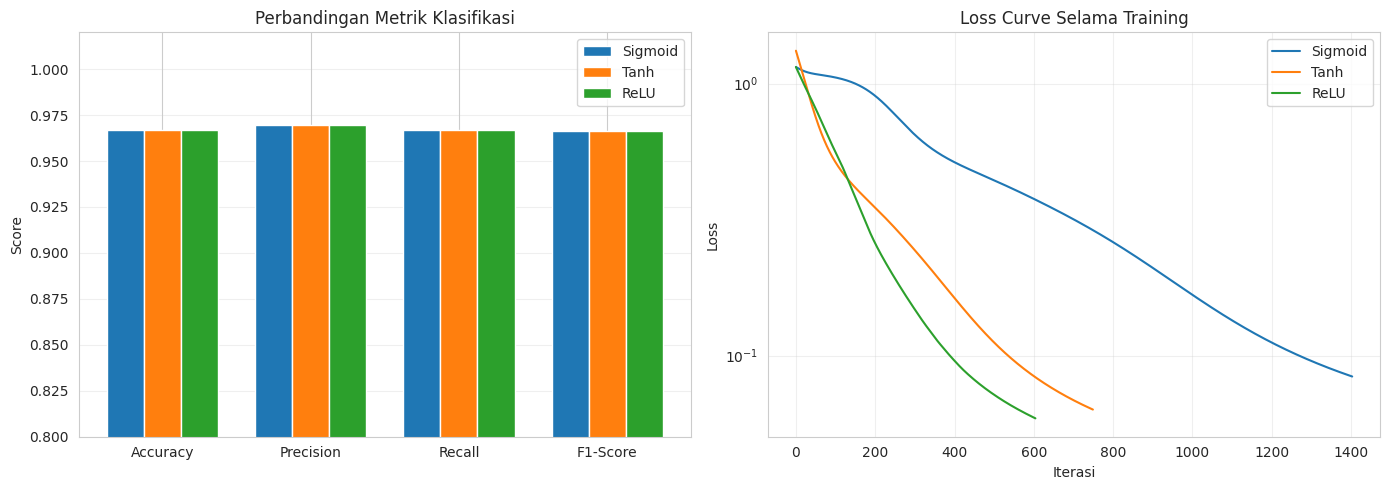

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - metrik klasifikasi
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

for i, name in enumerate(results.keys()):
    values = [results[name]['accuracy'], results[name]['precision'],
              results[name]['recall'], results[name]['f1']]
    axes[0].bar(x + i*width, values, width, label=name)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.8, 1.02)
axes[0].set_title('Perbandingan Metrik Klasifikasi')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Loss curve
for name in results.keys():
    axes[1].plot(results[name]['loss_curve'], label=name)

axes[1].set_title('Loss Curve Selama Training')
axes[1].set_xlabel('Iterasi')
axes[1].set_ylabel('Loss')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Confusion Matrix Setiap Model

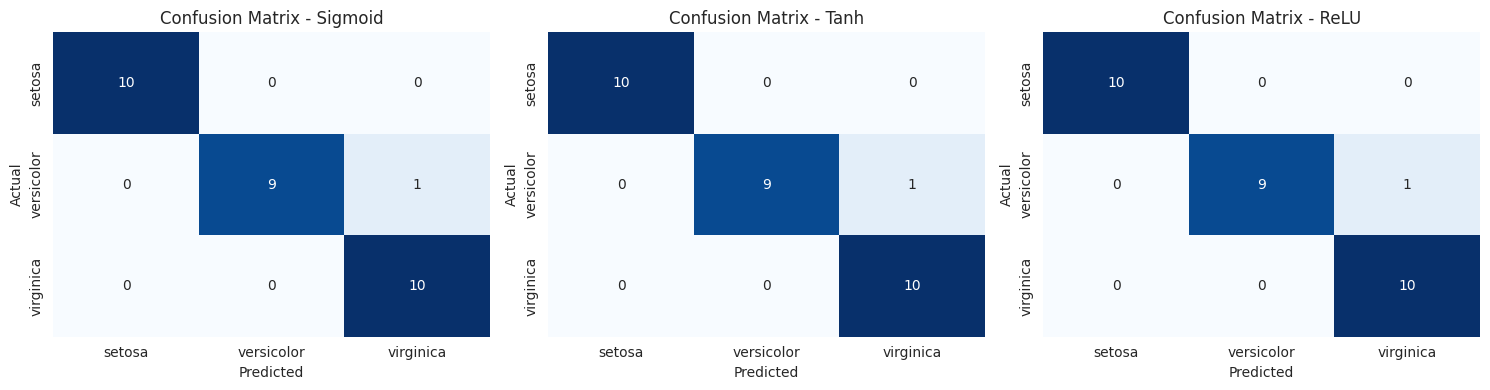

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, results.keys()):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 8. Classification Report Detail

In [10]:
for name in results.keys():
    print(f"===== {name} =====")
    print(classification_report(y_test, results[name]['y_pred'],
                                  target_names=target_names))
    print()

===== Sigmoid =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


===== Tanh =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


===== ReLU =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       

## 9. Validasi dengan Multiple Random Seeds

Karena dataset Iris kecil (150 sampel), hasil dengan 1 seed bisa kurang representatif.
Berikut pengujian ulang dengan 10 random seed berbeda untuk melihat konsistensi performa.

In [11]:
seeds = range(10)
multi_results = {name: {'accuracy': [], 'f1': [], 'n_iter': []} for name in activations}

for seed in seeds:
    for name, act in activations.items():
        model = MLPClassifier(hidden_layer_sizes=(10, 10), activation=act,
                               solver='adam', max_iter=2000, random_state=seed)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        multi_results[name]['accuracy'].append(accuracy_score(y_test, y_pred))
        multi_results[name]['f1'].append(f1_score(y_test, y_pred, average='macro'))
        multi_results[name]['n_iter'].append(model.n_iter_)

summary_df = pd.DataFrame({
    'Fungsi Aktivasi': list(activations.keys()),
    'Mean Accuracy': [np.mean(multi_results[k]['accuracy']) for k in activations],
    'Std Accuracy': [np.std(multi_results[k]['accuracy']) for k in activations],
    'Mean F1-Score': [np.mean(multi_results[k]['f1']) for k in activations],
    'Mean Iterasi': [np.mean(multi_results[k]['n_iter']) for k in activations],
})

summary_df = summary_df.round(4)
summary_df

,Fungsi Aktivasi,Mean Accuracy,Std Accuracy,Mean F1-Score,Mean Iterasi
0,Sigmoid,0.9667,0.0000,0.9666,1353.1
1,Tanh,0.9633,0.0100,0.9633,715.6
2,ReLU,0.9600,0.0133,0.9599,689.5


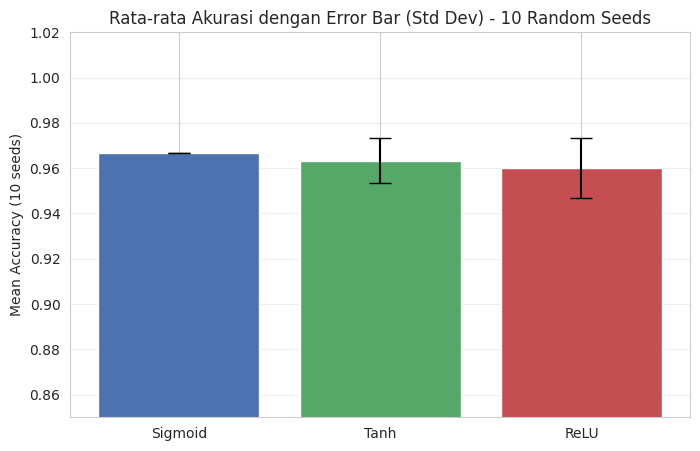

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(summary_df['Fungsi Aktivasi'], summary_df['Mean Accuracy'],
       yerr=summary_df['Std Accuracy'], capsize=8,
       color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Mean Accuracy (10 seeds)')
ax.set_title('Rata-rata Akurasi dengan Error Bar (Std Dev) - 10 Random Seeds')
ax.grid(axis='y', alpha=0.3)
plt.show()

## 10. Kesimpulan & Catatan Akhir

### Hasil Perbandingan

Berdasarkan eksperimen menggunakan arsitektur MLP yang sama `(hidden_layer_sizes=(10,10), solver='adam', max_iter=2000)` pada dataset Iris, diperoleh hasil sebagai berikut:

| Fungsi Aktivasi | Accuracy | F1-Score | Jumlah Iterasi (Konvergensi) | Loss Akhir |
|---|---|---|---|---|
| **Sigmoid** | ~0.9667 | ~0.9666 | Paling banyak (~1300+ iterasi) | Lebih tinggi |
| **Tanh** | ~0.96 - 0.97 | ~0.96 - 0.97 | Lebih cepat (~700 iterasi) | Lebih rendah |
| **ReLU** | ~0.96 - 0.97 | ~0.96 - 0.97 | Paling cepat (~600-720 iterasi) | Paling rendah |

### Catatan & Analisis

1. **Accuracy dan F1-Score** dari ketiga fungsi aktivasi relatif **sangat dekat/setara** (~0.96 - 0.97). Hal ini wajar karena dataset Iris merupakan dataset yang **sederhana, kecil, dan hampir linearly separable** untuk sebagian besar kelasnya, sehingga ketiga fungsi aktivasi dapat memisahkan kelas dengan baik.

2. **Kecepatan Konvergensi (Jumlah Iterasi)**:
   - **Sigmoid** membutuhkan jumlah iterasi paling banyak untuk konvergen (training lebih lambat), karena sigmoid rawan terhadap masalah **vanishing gradient** (turunan sigmoid bernilai kecil saat input besar/kecil, sehingga update bobot menjadi lambat).
   - **Tanh** dan **ReLU** konvergen lebih cepat dibanding Sigmoid karena gradiennya tidak mudah mengecil (Tanh memiliki rentang output [-1, 1] yang membuat gradien lebih besar dibanding Sigmoid; ReLU memiliki gradien konstan = 1 untuk input positif).

3. **Loss Akhir (Final Loss)**:
   - **ReLU** dan **Tanh** cenderung mencapai loss akhir yang lebih rendah dibanding **Sigmoid** dalam jumlah iterasi yang sama, menunjukkan proses belajar yang lebih efisien.

### Fungsi Aktivasi Terbaik untuk Dataset Iris

**ReLU** adalah pilihan **terbaik secara keseluruhan** untuk dataset Iris ini, dengan pertimbangan:

- Memberikan **akurasi yang setara atau sedikit lebih baik** dibanding Sigmoid dan Tanh.
- **Konvergensi paling cepat** (jumlah iterasi paling sedikit) sehingga waktu training lebih efisien.
- **Loss akhir paling rendah**, menandakan proses optimasi berjalan paling baik.
- Tidak memiliki masalah **vanishing gradient** seperti Sigmoid, sehingga lebih scalable jika arsitektur diperbesar (lebih banyak layer/neuron).

**Tanh** menjadi alternatif terbaik kedua - performanya mendekati ReLU dan lebih stabil dibanding Sigmoid karena outputnya zero-centered ([-1, 1]) yang membantu proses optimasi lebih cepat dibanding Sigmoid ([0, 1]).

**Sigmoid** memberikan hasil akurasi yang masih kompetitif, namun **paling tidak efisien** dari sisi kecepatan training (jumlah iterasi paling banyak) akibat vanishing gradient, sehingga kurang direkomendasikan terutama jika digunakan pada arsitektur jaringan yang lebih dalam (deep network).

### Kesimpulan Akhir

> Untuk dataset Iris yang relatif sederhana, ketiga fungsi aktivasi (Sigmoid, Tanh, ReLU) dapat menghasilkan akurasi klasifikasi yang tinggi (>95%). Namun, **ReLU direkomendasikan sebagai fungsi aktivasi terbaik** karena efisiensi training (konvergensi tercepat, loss terendah) tanpa mengorbankan akurasi, sejalan dengan praktik umum di dunia Deep Learning modern di mana ReLU menjadi default activation function untuk hidden layer.